# Notebook 2: DO vs HO vs DOHO vs RL-DOHO on high-dimensional gene-expression data

Notebook 1 showed that, on the 14-feature rheumatic dataset, every method reaches nearly the same best subsets: there is an accuracy ceiling.
This notebook tests the same four algorithms where feature selection is genuinely hard: **thousands of genes and few patients**.

| Dataset | Patients | Genes (features) | Classes |
|---|---|---|---|
| Colon cancer | 62 | 2,000 | 2 |
| ALL/AML leukaemia | 72 | 7,129 | 2 |
| Lung cancer | 203 | 3,312 | 5 |
| Glioma | 50 | 4,434 | 4 |

The datasets come from the scikit-feature benchmark repository (Li et al., 2017) and are downloaded automatically from GitHub.

**Algorithms:** identical to Notebook 1 (same code, same update rules): DO, HO, DOHO, and RL-DOHO (DO exploration + UCB bandit over PERTURB / RESTART / DO / HO when the search stalls, tabu memory, elitism, parsimony tie-break).

**Protocol (standard for wrapper feature selection on microarray data):**
- For each seed: a stratified 70/30 train/test split (the split changes with the seed, so results average over 10 different splits).
- Min-max scaling fitted on the training part only.
- Fitness = 0.99 × (1 − 5-fold CV accuracy of KNN, k=5, on the training part) + 0.01 × (selected / total features). KNN is the usual wrapper classifier in this literature: fast, and sensitive to irrelevant features.
- Test accuracy = KNN trained on the training part with the selected genes, scored on the held-out 30%.
- Budget: 20 agents × 50 iterations for every algorithm (1,020 fitness evaluations per run).

**Note on small test sets:** with 15–61 test patients, one patient is worth 2–7 accuracy points. Fitness (CV on the training part) is the more stable comparison; test accuracy is reported alongside.

**Sections:** 1 setup · 2 config · 3 data · 4 fitness · 5 helpers · 6 algorithms · 7 detailed run (every iteration printed) · 8 benchmark · 9 results and statistics per dataset · 10 ablation across datasets · 11 overall ranking

In [1]:
# ================= 1. SETUP =================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os, time, pickle, warnings, urllib.request
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
from scipy.stats import wilcoxon, friedmanchisquare
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [2]:
# ================= 2. CONFIG =================
OUT_DIR  = '/content/drive/MyDrive/rl_doho_results_hd' if IN_COLAB else 'rl_doho_results_hd'
DATA_DIR = f"{OUT_DIR}/data"
DATASETS = ["colon", "ALLAML", "lung", "GLIOMA"]
SEEDS    = list(range(10))
POP_SIZE, MAX_ITER = 20, 50
KNN_K, CV_FOLDS, TEST_SIZE = 5, 5, 0.3
ALPHA, BETA = 0.99, 0.01

# RL-DOHO settings: identical to Notebook 1
STAG_TRIGGER, UCB_C, TABU_TENURE, TIE_EPS = 2, 1.0, None, 0.001

DETAIL_DATASET, DETAIL_SEED = "colon", 0   # section 7: one run per algorithm with every iteration printed
VERBOSE      = False                       # True prints every iteration of every benchmark run (very long)
RUN_ABLATION = True

os.makedirs(DATA_DIR, exist_ok=True)
ALGOS = ["DO", "HO", "DOHO", "RL-DOHO"]; PROPOSED = "RL-DOHO"
COLORS = {"DO": "#2a78d6", "HO": "#eb6834", "DOHO": "#1baf7a", "RL-DOHO": "#eda100"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})
print("Output folder:", OUT_DIR)

Output folder: /content/drive/MyDrive/rl_doho_results_hd


## 3. Data: download once, then load from Drive

In [3]:
URL = "https://raw.githubusercontent.com/jundongl/scikit-feature/master/skfeature/data/{}.mat"
DATA = {}
for name in DATASETS:
    path = f"{DATA_DIR}/{name}.mat"
    if not os.path.exists(path):
        urllib.request.urlretrieve(URL.format(name), path)
    d = sio.loadmat(path)
    X, y = d["X"].astype(float), d["Y"].ravel()
    DATA[name] = (X, y)

info = pd.DataFrame([{"dataset": n, "patients": X.shape[0], "genes": X.shape[1], "classes": len(np.unique(y)),
                      "class sizes": dict(zip(*[v.tolist() for v in np.unique(y, return_counts=True)])),
                      "search space": f"2^{X.shape[1]}"} for n, (X, y) in DATA.items()])
info

,dataset,patients,genes,classes,class sizes,search space
0,colon,62,2000,2,"{-1: 40, 1: 22}",2^2000
1,ALLAML,72,7129,2,"{1: 47, 2: 25}",2^7129
2,lung,203,3312,5,"{1: 139, 2: 17, 3: 21, 4: 20, 5: 6}",2^3312
3,GLIOMA,50,4434,4,"{1: 14, 2: 7, 3: 14, 4: 15}",2^4434


## 4. Fitness function (KNN, CV on the training part only) and test evaluation

In [4]:
COUNTER = {"calls": 0, "new": 0}
def mask_str(m): return np.packbits(np.asarray(m, dtype=np.uint8)).tobytes().hex()   # compact key for long masks

def use_dataset(name, seed):
    # Set the active dataset and split. Each (dataset, seed) has its own split, scaler and fitness cache.
    global X_tr, X_te, y_tr, y_te, N_FEATURES, FEATURES, _cache, CV, CUR
    X, y = DATA[name]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=seed)
    sc = MinMaxScaler().fit(X_tr); X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
    N_FEATURES = X.shape[1]; FEATURES = [f"g{i}" for i in range(N_FEATURES)]
    CV = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=seed)
    CUR = (name, seed)
    cf = f"{OUT_DIR}/cache_{name}_s{seed}.pkl"
    _cache = pickle.load(open(cf, "rb")) if os.path.exists(cf) else {}

def save_cache(): pass                     # called by the logger; the cache is saved once per (dataset, seed) instead
def save_cache_now(): pickle.dump(_cache, open(f"{OUT_DIR}/cache_{CUR[0]}_s{CUR[1]}.pkl", "wb"))

def fitness_function(mask, X_=None, y_=None):
    COUNTER["calls"] += 1
    key = mask_str(mask)
    if key in _cache: return _cache[key]["fit"]
    sel = np.flatnonzero(mask)
    if len(sel) == 0:
        _cache[key] = {"fit": 1.0, "acc": 0.0}; return 1.0
    acc = cross_val_score(KNeighborsClassifier(KNN_K), X_tr[:, sel], y_tr, cv=CV).mean()
    f = ALPHA * (1 - acc) + BETA * len(sel) / len(mask)
    _cache[key] = {"fit": f, "acc": acc}; COUNTER["new"] += 1
    return f

def evaluate_on_test(mask):
    sel = np.flatnonzero(mask)
    p = KNeighborsClassifier(KNN_K).fit(X_tr[:, sel], y_tr).predict(X_te[:, sel])
    return {"acc": float(np.mean(p == y_te)), "f1": float(f1_score(y_te, p, average="macro")), "pred": p}

for name in DATASETS:
    use_dataset(name, 0)
    t = time.time(); fa = fitness_function(np.ones(N_FEATURES, int))
    print(f"{name:7s}: one fitness evaluation {time.time()-t:.2f}s | all genes: CV acc={_cache[mask_str(np.ones(N_FEATURES, int))]['acc']:.3f}, "
          f"test acc={evaluate_on_test(np.ones(N_FEATURES, int))['acc']:.3f}  (train {len(y_tr)}, test {len(y_te)} patients)")

colon  : one fitness evaluation 0.04s | all genes: CV acc=0.694, test acc=0.789  (train 43, test 19 patients)
ALLAML : one fitness evaluation 0.02s | all genes: CV acc=0.800, test acc=0.864  (train 50, test 22 patients)
lung   : one fitness evaluation 0.02s | all genes: CV acc=0.950, test acc=0.902  (train 142, test 61 patients)
GLIOMA : one fitness evaluation 0.01s | all genes: CV acc=0.686, test acc=0.867  (train 35, test 15 patients)


## 5. Shared helpers: binarization and the per-iteration logger (same as Notebook 1)

In [5]:
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def binarize(position): return (sigmoid(position) > 0.5).astype(int)
def mask_disp(m):   # bit string for small problems, a count for high-dimensional ones
    return mask_str(m) if N_FEATURES <= 40 else f"{int(np.sum(m))}/{N_FEATURES} selected"

class IterLogger:
    # Records and prints every iteration of a run.
    def __init__(self, algo, seed, verbose=True):
        self.algo, self.seed, self.verbose = algo, seed, verbose
        self.rows, self.t0, self.seen = [], time.time(), set()
        if verbose:
            print(f"\n{'='*118}\n{algo}  | seed={seed} | pop={POP_SIZE} | iters={MAX_ITER}\n{'='*118}")
            print(f"{'iter':>4} | {'action':<14}| {'best':>7} {'genbest':>7} {'mean':>7} {'worst':>7} | "
                  f"{'#f':>5} | {'best mask':<{min(N_FEATURES, 40) if N_FEATURES <= 40 else 18}} | {'div':>5} | {'new':>3} | {'sec':>5}")

    def log(self, t, action, positions, fitness, best_fit, best_mask, reward=None):
        pm = np.array([binarize(p) for p in positions])
        fresh = {mask_str(m) for m in pm} - self.seen; new = len(fresh); self.seen |= fresh
        row = dict(iter=t, action=action, best=best_fit, gen_best=float(np.min(fitness)),
                   mean=float(np.mean(fitness)), worst=float(np.max(fitness)),
                   n_feats=int(best_mask.sum()), best_mask=best_mask.copy() if N_FEATURES <= 40 else None,
                   pop_masks=pm if N_FEATURES <= 40 else None,
                   diversity=float(np.mean(np.std(positions, axis=0))), new_evals=new,
                   reward=reward, sec=time.time() - self.t0)
        self.rows.append(row)
        if self.verbose:
            rw = f" r={reward:+.3f}" if reward is not None else ""
            print(f"{t:>4} | {action:<14}| {row['best']:.4f} {row['gen_best']:.4f} {row['mean']:.4f} {row['worst']:.4f} | "
                  f"{row['n_feats']:>5} | {mask_disp(best_mask)} | {row['diversity']:.3f} | {new:>3} | {row['sec']:5.1f}{rw}")
        self.t0 = time.time()

    def finish(self, best_fit, best_mask):
        if self.verbose:
            sel = [FEATURES[i] for i in np.flatnonzero(best_mask)]
            print(f"    ('new' = subsets this run had not evaluated before; {len(self.seen)} distinct subsets in total)")
            print(f"--> {self.algo} done: best fitness={best_fit:.4f}, CV acc={_cache[mask_str(best_mask)]['acc']:.4f}, "
                  f"{len(sel)} features" + (f": {sel}" if len(sel) <= 15 else f" (first 10: {sel[:10]})"))
        save_cache()
        return pd.DataFrame(self.rows)

## 6. The algorithms (identical code to Notebook 1)

In [6]:
def _init(rng, dim):
    positions = rng.uniform(-1, 1, size=(POP_SIZE, dim))
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    b = np.argmin(fitness)
    return positions, masks, fitness, positions[b].copy(), masks[b].copy(), fitness[b]

def _evaluate_and_update(positions, fitness, best_position, best_mask, best_fitness, t):
    # Elitism (worst of previous generation gets the best), evaluate, update the global best.
    worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1
    positions[worst_idx] = best_position.copy()
    masks = np.array([binarize(p) for p in positions])
    fitness = np.array([fitness_function(m) for m in masks])
    g = np.argmin(fitness); improved = fitness[g] < best_fitness
    if improved:
        best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
    return masks, fitness, best_position, best_mask, best_fitness, improved

# ---------------- DO ----------------
def dandelion_optimizer(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "rising" if progress < 0.4 else ("descending" if progress < 0.8 else "landing")
        for i in range(POP_SIZE):
            if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
            elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:                positions[i] += rng.normal(0, 0.1, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, phase, positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- HO ----------------
def hippopotamus_optimization(seed=42, verbose=True):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("HO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        n_mv = [0, 0, 0]
        for i in range(POP_SIZE):
            r = rng.random()
            if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6; n_mv[0] += 1
            elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i]); n_mv[1] += 1
            else:         positions[i] += rng.normal(0, 0.6, dim); n_mv[2] += 1
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"mv{n_mv[0]}/df{n_mv[1]}/ev{n_mv[2]}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

# ---------------- Fixed DOHO ----------------
def doho_fixed(seed=42, verbose=True, switch_point=0.5):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger("DOHO", seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        phase = "DO" if progress <= switch_point else "HO"
        for i in range(POP_SIZE):
            if phase == "DO":
                if progress < switch_point * 0.6: positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                else: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            else:
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            positions[i] = np.clip(positions[i], -3, 3)
        masks, fitness, best_position, best_mask, best_fitness, _ = _evaluate_and_update(
            positions, fitness, best_position, best_mask, best_fitness, t)
        L.log(t, f"phase {phase}", positions, fitness, best_fitness, best_mask)
    return best_mask, best_fitness, L.finish(best_fitness, best_mask)

In [7]:
# ---------------- Previous RL-DOHO (Q-learning controller, v10): used only in the ablation ----------------
ACTION_NAMES = {0: "DO", 1: "HO", 2: "PERTURB", 3: "RESTART"}

class QLearningController:
    def __init__(self, n_actions=4, alpha=0.5, gamma=0.5, epsilon=0.3, epsilon_decay=0.85, seed=42):
        self.rng = np.random.default_rng(seed); self.q_table = {}
        self.alpha, self.gamma, self.epsilon, self.epsilon_decay, self.n_actions = alpha, gamma, epsilon, epsilon_decay, n_actions
    def get_state(self, positions, stagnation, progress):
        div = np.mean(np.std(positions, axis=0))
        return (int(div >= 0.8), int(stagnation >= 3), int(progress >= 0.5))
    def _q(self, s):
        if s not in self.q_table: self.q_table[s] = np.zeros(self.n_actions)
        return self.q_table[s]
    def choose_action(self, state):
        q = self._q(state)
        if self.rng.random() < self.epsilon: return int(self.rng.integers(0, self.n_actions)), "explore"
        best = np.flatnonzero(q == q.max())                 # random tie-break, not always action 0
        return int(self.rng.choice(best)), "greedy"
    def update(self, s, a, r, s2):
        q = self._q(s); q[a] += self.alpha * (r + self.gamma * np.max(self._q(s2)) - q[a])
    def decay_epsilon(self): self.epsilon = max(0.05, self.epsilon * self.epsilon_decay)

def rl_doho_qlearning(seed=42, verbose=True, perturb_frac=0.15, controller=None, name="RL-DOHO (Q-learning)"):
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = controller(seed) if controller else QLearningController(seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    stagnation = 0; k = max(1, int(round(dim * perturb_frac)))
    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        state = agent.get_state(positions, stagnation, progress)
        action, how = agent.choose_action(state)
        order = np.argsort(fitness); worst_half = set(order[POP_SIZE // 2:])
        prev_top = np.mean(np.sort(fitness)[:POP_SIZE // 2]); prev_best = best_fitness
        for i in range(POP_SIZE):
            if action == 0:                                   # DO move
                if progress < 0.4:   positions[i] += rng.normal(0, 1, dim) * (1 - progress)
                elif progress < 0.8: positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
                else:                positions[i] += rng.normal(0, 0.1, dim)
            elif action == 1:                                 # HO move
                r = rng.random()
                if r < 0.5:   positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.6
                elif r < 0.8: positions[i] += rng.uniform(0.2, 0.7) * (best_position - positions[i])
                else:         positions[i] += rng.normal(0, 0.6, dim)
            elif i in worst_half:                             # disruptive actions only hit the worst half
                if action == 2:                               # flip k bits of the best solution
                    p = best_position.copy(); d = rng.choice(dim, k, replace=False)
                    p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); positions[i] = p
                else:                                         # restart
                    positions[i] = rng.uniform(-1, 1, dim)
            else:                                             # good half keeps exploiting
                positions[i] += rng.uniform(0, 1, dim) * (best_position - positions[i]) * 0.5
            positions[i] = np.clip(positions[i], -3, 3)
        positions[order[-1]] = best_position.copy()          # elitism
        masks = np.array([binarize(p) for p in positions])
        fitness = np.array([fitness_function(m) for m in masks])
        g = np.argmin(fitness)
        if fitness[g] < best_fitness:
            best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy(); stagnation = 0
        else:
            stagnation += 1
        new_top = np.mean(np.sort(fitness)[:POP_SIZE // 2])
        reward = 100 * (prev_best - best_fitness) + 10 * (prev_top - new_top)
        agent.update(state, action, reward, agent.get_state(positions, stagnation, min((t + 1) / MAX_ITER, 1.0)))
        agent.decay_epsilon()
        L.log(t, f"{ACTION_NAMES[action]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["rl_action"] = ["init"] + [a.split("(")[0] for a in hist["action"][1:]]
    hist.attrs["q_table"] = {s: q.copy() for s, q in agent.q_table.items()}
    return best_mask, best_fitness, hist

RUNNERS = {"DO": dandelion_optimizer, "HO": hippopotamus_optimization, "DOHO": doho_fixed}

In [8]:
# ---------------- RL-DOHO (proposed): DO + HO + UCB bandit controller ----------------
ARMS = ("PERTURB", "RESTART", "DO", "HO")

class UCBBandit:
    # UCB1 multi-armed bandit (single-state reinforcement learning). Rewards are in [0, 1].
    def __init__(self, n_arms=3, c=1.0, seed=42):
        self.rng = np.random.default_rng(seed); self.c = c
        self.n = np.zeros(n_arms); self.value = np.zeros(n_arms)
    def choose(self):
        untried = np.flatnonzero(self.n == 0)
        if len(untried): return int(self.rng.choice(untried)), "init"
        ucb = self.value + self.c * np.sqrt(2 * np.log(self.n.sum()) / self.n)
        return int(self.rng.choice(np.flatnonzero(np.isclose(ucb, ucb.max())))), "ucb"
    def update(self, arm, r):
        self.n[arm] += 1; self.value[arm] += (r - self.value[arm]) / self.n[arm]

class RandomArm(UCBBandit):              # ablation: same trigger, arm chosen at random
    def choose(self): return int(self.rng.integers(len(self.n))), "random"

class FixedArm(UCBBandit):               # ablation: same trigger, always the same arm
    def __init__(self, arm, seed, n_arms=4): super().__init__(n_arms=n_arms, seed=seed); self.arm = arm
    def choose(self): return self.arm, "fixed"

def _do_move(rng, pos, best_position, progress, dim):
    # DO's movement equations, unchanged
    if progress < 0.4:   pos = pos + rng.normal(0, 1, dim) * (1 - progress)
    elif progress < 0.8: pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.5
    else:                pos = pos + rng.normal(0, 0.1, dim)
    return np.clip(pos, -3, 3)

def _ho_move(rng, pos, best_position, dim):
    # HO's movement equations, unchanged
    r = rng.random()
    if r < 0.5:   pos = pos + rng.uniform(0, 1, dim) * (best_position - pos) * 0.6
    elif r < 0.8: pos = pos + rng.uniform(0.2, 0.7) * (best_position - pos)
    else:         pos = pos + rng.normal(0, 0.6, dim)
    return np.clip(pos, -3, 3)

def rl_doho(seed=42, verbose=True, bandit=None, name="RL-DOHO", arms=ARMS, k_max=3, tabu_tries=20, tie_eps=None):
    tie_eps = TIE_EPS if tie_eps is None else tie_eps
    def better(f, nf, bf, bnf):   # strictly better, or a tie within tie_eps with fewer features
        return f < bf - tie_eps or (abs(f - bf) <= tie_eps and (nf < bnf or (nf == bnf and f < bf)))
    rng = np.random.default_rng(seed); dim = N_FEATURES
    agent = bandit(seed) if bandit else UCBBandit(n_arms=len(arms), c=UCB_C, seed=seed)
    positions, masks, fitness, best_position, best_mask, best_fitness = _init(rng, dim)
    L = IterLogger(name, seed, verbose); L.log(0, "init", positions, fitness, best_fitness, best_mask)
    tabu = {mask_str(m): 0 for m in masks}            # subset -> last iteration it was visited
    def is_tabu(key, t): return key in tabu and (TABU_TENURE is None or t - tabu[key] <= TABU_TENURE)
    def tabu_draw(make, t):
        for _ in range(tabu_tries):
            p = make(); key = mask_str(binarize(p))
            if not is_tabu(key, t): break
        tabu[key] = t                                  # reserve it so two agents don't draw the same subset
        return np.clip(p, -3, 3)
    stagnation = 0

    for t in range(1, MAX_ITER + 1):
        progress = t / MAX_ITER
        prev_best, prev_median = best_fitness, float(np.median(fitness))
        order = np.argsort(fitness); worst_half = order[POP_SIZE // 2:]
        if stagnation < STAG_TRIGGER:                  # ---- improving: plain DO exploration
            arm, how = None, None
            for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
            touched = np.arange(POP_SIZE)
        else:                                          # ---- stalled: the bandit picks an arm
            arm, how = agent.choose()
            if arms[arm] == "DO":
                for i in range(POP_SIZE): positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                touched = np.arange(POP_SIZE)
            elif arms[arm] == "HO":
                for i in range(POP_SIZE): positions[i] = _ho_move(rng, positions[i], best_position, dim)
                touched = np.arange(POP_SIZE)
            else:
                for i in order[:POP_SIZE // 2]:        # better half keeps DO's movement
                    positions[i] = _do_move(rng, positions[i], best_position, progress, dim)
                for i in worst_half:
                    if arms[arm] == "PERTURB":     # flip 1..k_max features of the best subset
                        def make():
                            p = best_position.copy(); k = int(rng.integers(1, k_max + 1))
                            d = rng.choice(dim, k, replace=False)
                            p[d] = -np.sign(p[d] + 1e-12) * rng.uniform(0.5, 2.0, k); return p
                    else:                              # RESTART: fresh random subset
                        make = lambda: rng.uniform(-1, 1, dim)
                    positions[i] = tabu_draw(make, t)
                touched = worst_half
        worst_idx = np.argmax(fitness) if t > 1 else POP_SIZE - 1     # elitism, same rule as DO
        positions[worst_idx] = best_position.copy()
        masks = np.array([binarize(p) for p in positions])
        for m in masks: tabu[mask_str(m)] = t
        fitness = np.array([fitness_function(m) for m in masks])
        improved = False
        for g in np.argsort(fitness):                  # best candidate under the parsimony rule
            if better(fitness[g], masks[g].sum(), best_fitness, best_mask.sum()):
                best_fitness, best_position, best_mask = fitness[g], positions[g].copy(), masks[g].copy()
                improved = True
        stagnation = 0 if improved else stagnation + 1
        if arm is None:
            L.log(t, "DO-explore", positions, fitness, best_fitness, best_mask)
        else:
            # reward: 1 for a new global best, otherwise up to 0.2 for the share of the arm's
            # candidates that beat the previous population median
            touched = [i for i in touched if i != worst_idx]
            share = np.mean([fitness[i] < prev_median for i in touched]) if touched else 0.0
            reward = 1.0 if improved else 0.2 * share
            agent.update(arm, reward)
            L.log(t, f"{arms[arm]}({how[0]})", positions, fitness, best_fitness, best_mask, reward=reward)
    hist = L.finish(best_fitness, best_mask)
    hist["arm"] = ["init"] + [("EXPLORE" if a == "DO-explore" else a.split("(")[0]) for a in hist["action"][1:]]
    hist.attrs["pulls"] = agent.n.copy(); hist.attrs["arm_value"] = agent.value.copy(); hist.attrs["arm_names"] = list(arms)
    return best_mask, best_fitness, hist

RUNNERS["RL-DOHO"] = rl_doho
print("Algorithms ready:", list(RUNNERS))

Algorithms ready: ['DO', 'HO', 'DOHO', 'RL-DOHO']


## 7. Detailed run: every iteration of every algorithm on one dataset and seed

In [9]:
use_dataset(DETAIL_DATASET, DETAIL_SEED)
detail = {}
for a in ALGOS:
    m, f, h = RUNNERS[a](seed=DETAIL_SEED, verbose=True)
    detail[a] = {"mask": m, "fit": f, "hist": h, "test": evaluate_on_test(m)}
save_cache_now()
print(f"\nTest accuracy on {DETAIL_DATASET}, seed {DETAIL_SEED} ({len(y_te)} test patients):")
for a in ALGOS:
    print(f"  {a:8s} fitness={detail[a]['fit']:.4f}  CV acc={_cache[mask_str(detail[a]['mask'])]['acc']:.4f}  "
          f"test acc={detail[a]['test']['acc']:.4f}  genes={int(detail[a]['mask'].sum())}")


DO  | seed=0 | pop=20 | iters=50
iter | action        |    best genbest    mean   worst |    #f | best mask          |   div | new |   sec
   0 | init          | 0.2387 0.2387 0.2799 0.3077 |   984 | 984/2000 selected | 0.558 |  20 |   0.0
   1 | rising        | 0.2387 0.2387 0.2812 0.3077 |   984 | 984/2000 selected | 1.064 |  19 |   0.2
   2 | rising        | 0.2387 0.2387 0.2768 0.3076 |   984 | 984/2000 selected | 1.335 |  19 |   0.2
   3 | rising        | 0.2387 0.2387 0.2859 0.3296 |   984 | 984/2000 selected | 1.492 |  19 |   0.2
   4 | rising        | 0.2387 0.2387 0.2836 0.3076 |   984 | 984/2000 selected | 1.581 |  19 |   0.2
   5 | rising        | 0.2387 0.2387 0.2823 0.3294 |   984 | 984/2000 selected | 1.661 |  19 |   0.2
   6 | rising        | 0.2387 0.2387 0.2825 0.3077 |   984 | 984/2000 selected | 1.683 |  19 |   0.2
   7 | rising        | 0.2386 0.2386 0.2811 0.3295 |   975 | 975/2000 selected | 1.698 |  19 |   0.2
   8 | rising        | 0.2386 0.2386 0.2791 0.3076 |

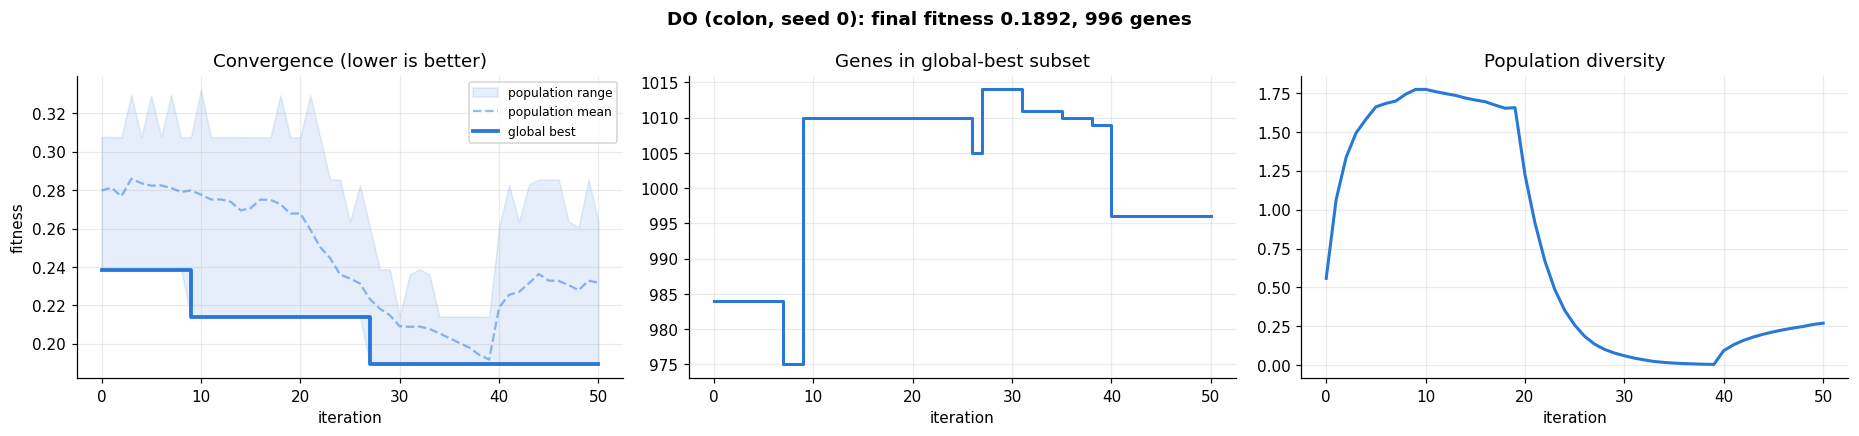

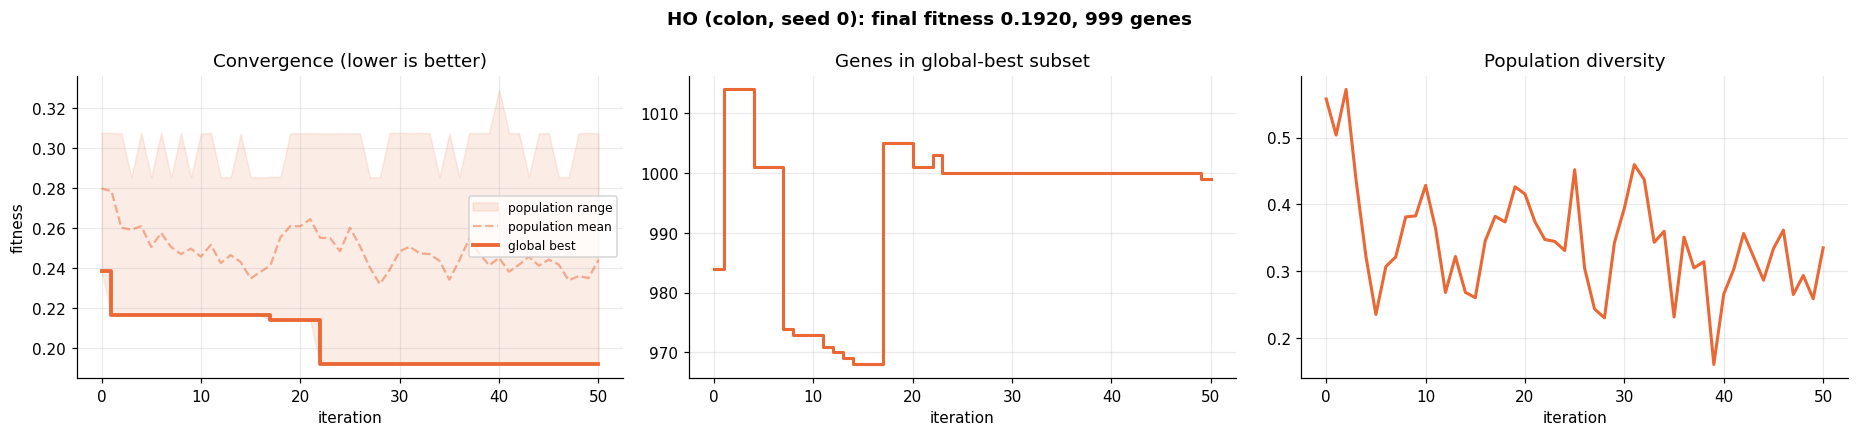

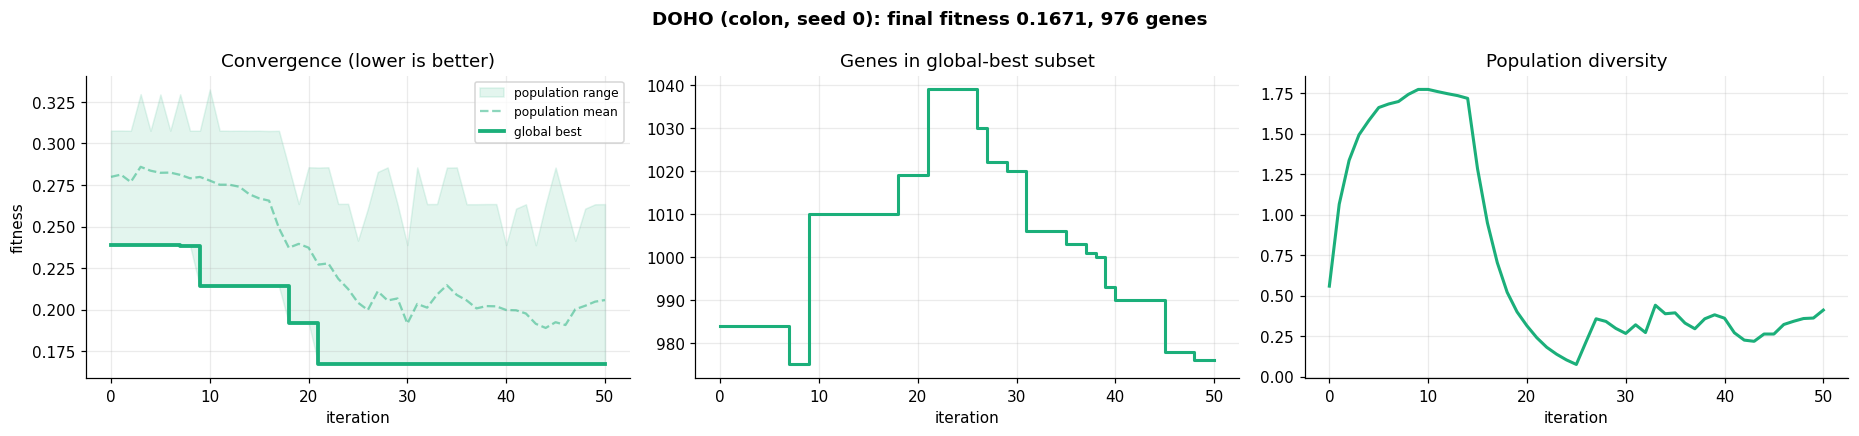

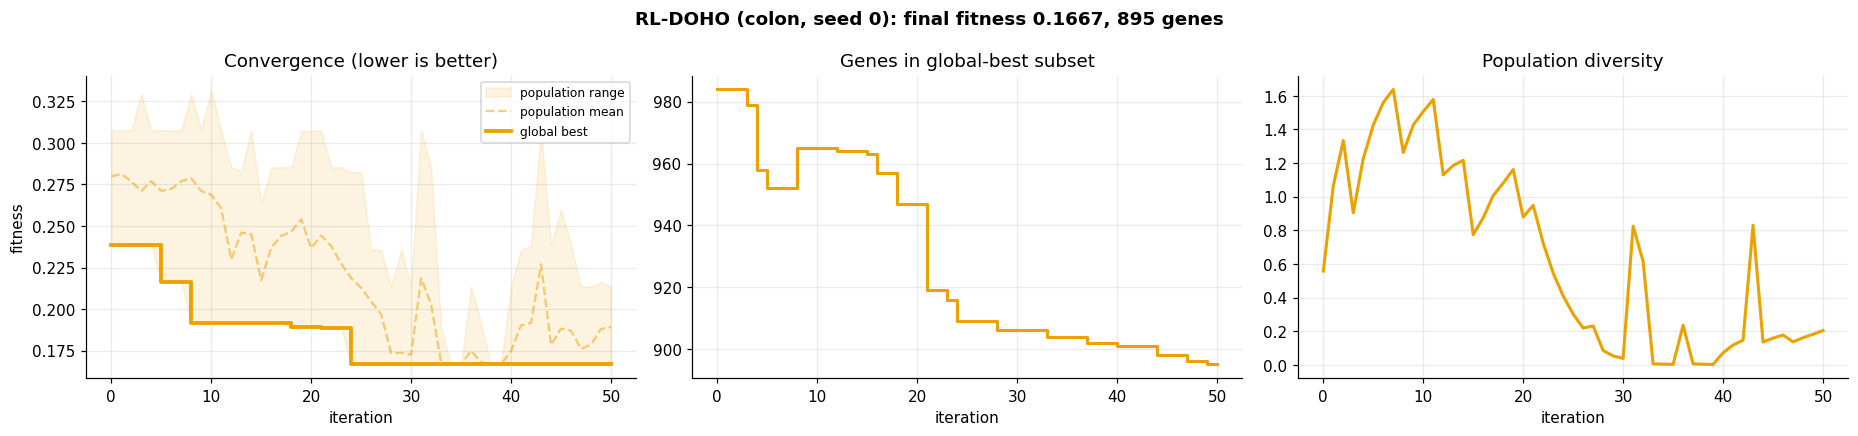

In [10]:
# One figure per algorithm: convergence, genes selected, diversity
def plot_algorithm(a, h, tag=""):
    c = COLORS[a]; x = h["iter"]
    fig, ax = plt.subplots(1, 3, figsize=(17, 4))
    fig.suptitle(f"{a}{tag}: final fitness {h['best'].iloc[-1]:.4f}, {h['n_feats'].iloc[-1]} genes", fontweight="bold")
    ax[0].fill_between(x, h["gen_best"], h["worst"], color=c, alpha=0.12, label="population range")
    ax[0].plot(x, h["mean"], color=c, alpha=0.5, lw=1.5, ls="--", label="population mean")
    ax[0].step(x, h["best"], where="post", color=c, lw=2.5, label="global best")
    ax[0].set_title("Convergence (lower is better)"); ax[0].set_xlabel("iteration"); ax[0].set_ylabel("fitness"); ax[0].legend(fontsize=8)
    ax[1].step(x, h["n_feats"], where="post", color=c); ax[1].set_title("Genes in global-best subset"); ax[1].set_xlabel("iteration")
    ax[2].plot(x, h["diversity"], color=c); ax[2].set_title("Population diversity"); ax[2].set_xlabel("iteration")
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/01_{a}_{DETAIL_DATASET}_s{DETAIL_SEED}.png", bbox_inches="tight"); plt.show()

for a in ALGOS: plot_algorithm(a, detail[a]["hist"], f" ({DETAIL_DATASET}, seed {DETAIL_SEED})")

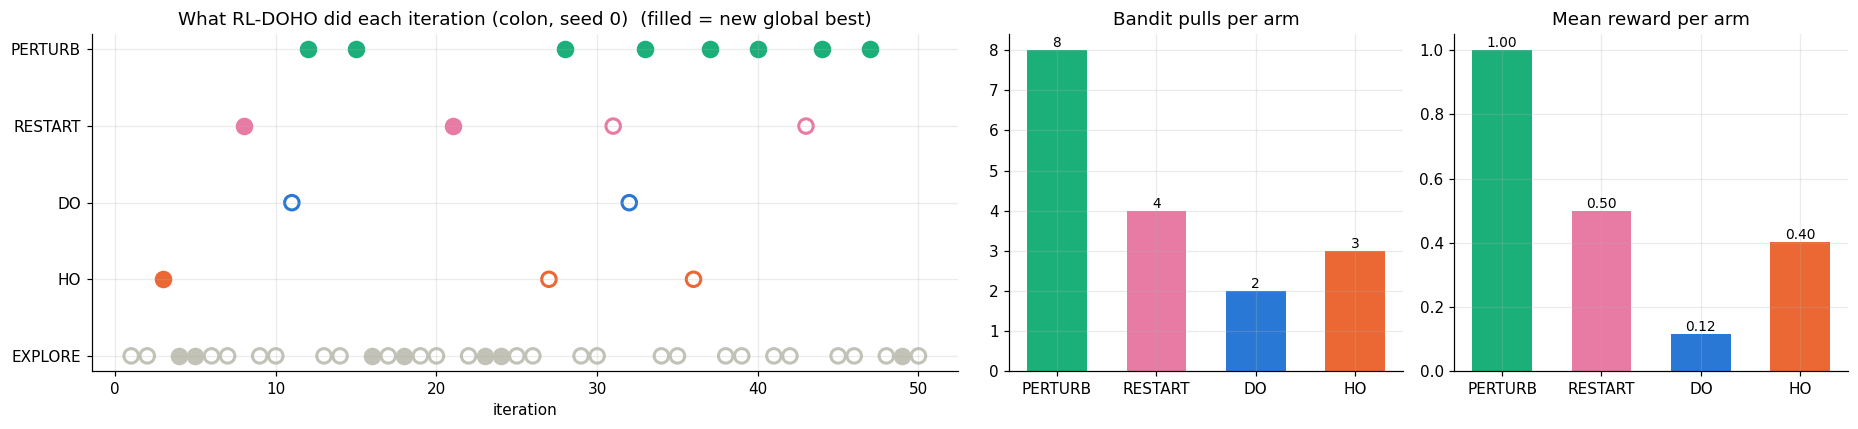

In [11]:
ARM_COL = {"EXPLORE": "#c3c2b7", "PERTURB": "#1baf7a", "RESTART": "#e87ba4", "DO": "#2a78d6", "HO": "#eb6834"}
def plot_ucb(h, tag="", fname="bandit"):
    hh = h.iloc[1:]
    lanes = ["EXPLORE"] + list(h.attrs.get("arm_names", ARMS))[::-1]
    improved = np.r_[False, np.diff(h["best"].values) < 0][1:]
    fig, ax = plt.subplots(1, 3, figsize=(17, 4), gridspec_kw={"width_ratios": [2.2, 1, 1]})
    for lane_i, lane in enumerate(lanes):
        sel = (hh["arm"] == lane).values
        ax[0].scatter(hh["iter"][sel & ~improved], [lane_i] * int((sel & ~improved).sum()), s=90, color=ARM_COL[lane],
                      marker="o", facecolors="none", linewidths=2)
        ax[0].scatter(hh["iter"][sel & improved], [lane_i] * int((sel & improved).sum()), s=110, color=ARM_COL[lane], marker="o")
    ax[0].set_yticks(range(len(lanes))); ax[0].set_yticklabels(lanes); ax[0].set_xlabel("iteration")
    ax[0].set_title(f"What RL-DOHO did each iteration{tag}  (filled = new global best)")
    arms = list(h.attrs.get("arm_names", ARMS)); pulls = h.attrs["pulls"]; val = h.attrs["arm_value"]
    ax[1].bar(arms, pulls, color=[ARM_COL[a] for a in arms], width=0.6); ax[1].set_title("Bandit pulls per arm")
    for i, v in enumerate(pulls): ax[1].text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=9)
    ax[2].bar(arms, val, color=[ARM_COL[a] for a in arms], width=0.6); ax[2].set_title("Mean reward per arm")
    for i, v in enumerate(val): ax[2].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/{fname}.png", bbox_inches="tight"); plt.show()

plot_ucb(detail["RL-DOHO"]["hist"], f" ({DETAIL_DATASET}, seed {DETAIL_SEED})", fname=f"02_rl_doho_bandit_{DETAIL_DATASET}")

## 8. Benchmark: 4 datasets × 10 seeds × 4 algorithms (resumable)
Every run is saved as soon as it finishes. If Colab disconnects, run this cell again and it skips finished runs. A dot is printed every 10 new fitness evaluations.

In [12]:
RES_FILE = f"{OUT_DIR}/hd_runs_p{POP_SIZE}_i{MAX_ITER}.pkl"
runs = pickle.load(open(RES_FILE, "rb")) if os.path.exists(RES_FILE) else {}
print(f"{len(runs)} runs already done")

def slim(h):  # keep the per-iteration curves, drop the large per-agent masks
    return h.drop(columns=[c for c in ("best_mask", "pop_masks") if c in h.columns])

def record(m, f, h):
    te = evaluate_on_test(m)
    return {"mask": np.packbits(m.astype(np.uint8)), "n": len(m), "fit": f, "cv_acc": _cache[mask_str(m)]["acc"],
            "test_acc": te["acc"], "test_f1": te["f1"], "n_feats": int(m.sum()), "hist": slim(h)}

t_start = time.time()
for ds in DATASETS:
    for s in SEEDS:
        todo = [a for a in ALGOS if (ds, a, s) not in runs]
        if not todo: continue
        use_dataset(ds, s)
        if ("ALL", ds, s) not in runs:
            runs[("ALL", ds, s)] = evaluate_on_test(np.ones(N_FEATURES, int))["acc"]
        for a in todo:
            if ds == DETAIL_DATASET and s == DETAIL_SEED and a in detail:
                m, f, h = detail[a]["mask"], detail[a]["fit"], detail[a]["hist"]
            else:
                m, f, h = RUNNERS[a](seed=s, verbose=VERBOSE)
            runs[(ds, a, s)] = record(m, f, h)
            pickle.dump(runs, open(RES_FILE, "wb"))
        save_cache_now()
        print(f"\n[{time.strftime('%H:%M:%S')}] {ds} seed {s}: " + "  ".join(
            f"{a}={runs[(ds, a, s)]['fit']:.4f}/{runs[(ds, a, s)]['test_acc']:.3f}" for a in ALGOS)
            + f"  (fitness/test acc)  elapsed {time.time() - t_start:.0f}s", flush=True)
print("\nBenchmark complete.")

0 runs already done

[17:00:08] colon seed 0: DO=0.1892/0.842  HO=0.1920/0.842  DOHO=0.1671/0.842  RL-DOHO=0.1667/0.842  (fitness/test acc)  elapsed 0s

[17:00:39] colon seed 1: DO=0.1175/0.421  HO=0.0955/0.579  DOHO=0.0735/0.632  RL-DOHO=0.1174/0.632  (fitness/test acc)  elapsed 32s

[17:01:15] colon seed 2: DO=0.1671/0.737  HO=0.1423/0.789  DOHO=0.1671/0.789  RL-DOHO=0.1424/0.789  (fitness/test acc)  elapsed 67s

[17:01:52] colon seed 3: DO=0.1919/0.737  HO=0.1918/0.737  DOHO=0.1918/0.789  RL-DOHO=0.1697/0.789  (fitness/test acc)  elapsed 105s

[17:02:27] colon seed 4: DO=0.2109/0.789  HO=0.1887/0.842  DOHO=0.2109/0.789  RL-DOHO=0.2108/0.789  (fitness/test acc)  elapsed 140s

[17:03:02] colon seed 5: DO=0.1862/0.737  HO=0.1423/0.684  DOHO=0.1642/0.737  RL-DOHO=0.1642/0.684  (fitness/test acc)  elapsed 175s

[17:03:35] colon seed 6: DO=0.0765/0.684  HO=0.0762/0.737  DOHO=0.0764/0.737  RL-DOHO=0.0760/0.684  (fitness/test acc)  elapsed 208s

[17:04:05] colon seed 7: DO=0.2387/0.842  HO=

## 9. Results per dataset

In [13]:
summary = pd.DataFrame([{"dataset": ds, "algo": a, "seed": s, **{k: v for k, v in r.items() if k not in ("mask", "hist", "n")}}
                        for (ds, a, s), r in runs.items() if ds != "ALL" and a in ALGOS and s in SEEDS and ds in DATASETS])
summary.to_csv(f"{OUT_DIR}/hd_per_run.csv", index=False)
table = summary.groupby(["dataset", "algo"], sort=False).agg(
    fit_mean=("fit", "mean"), fit_std=("fit", "std"), fit_worst=("fit", "max"),
    cv_acc=("cv_acc", "mean"), test_acc_mean=("test_acc", "mean"), test_acc_std=("test_acc", "std"),
    test_f1=("test_f1", "mean"), n_genes=("n_feats", "mean"))
allg = pd.Series({ds: np.mean([runs[("ALL", ds, s)] for s in SEEDS]) for ds in DATASETS}, name="all genes test acc")
table.to_csv(f"{OUT_DIR}/hd_summary.csv")
print("Test accuracy using ALL genes (no selection):"); print(allg.round(4).to_string()); print()
table.round(4)

Test accuracy using ALL genes (no selection):
colon     0.7263
ALLAML    0.8227
lung      0.9426
GLIOMA    0.8400



fit_mean  fit_std  fit_worst  cv_acc  test_acc_mean  \
dataset algo                                                           
colon   DO         0.1756   0.0476     0.2387  0.8275         0.7158   
        HO         0.1577   0.0428     0.1920  0.8456         0.7579   
        DOHO       0.1643   0.0512     0.2139  0.8389         0.7526   
        RL-DOHO    0.1617   0.0415     0.2108  0.8414         0.7526   
ALLAML  DO         0.1375   0.0265     0.1633  0.8660         0.8182   
        HO         0.1316   0.0298     0.1634  0.8720         0.8455   
        DOHO       0.1375   0.0281     0.1831  0.8660         0.8409   
        RL-DOHO    0.1395   0.0371     0.1831  0.8640         0.8364   
lung    DO         0.0439   0.0088     0.0607  0.9605         0.9393   
        HO         0.0438   0.0104     0.0606  0.9605         0.9492   
        DOHO       0.0432   0.0075     0.0539  0.9612         0.9393   
        RL-DOHO    0.0432   0.0067     0.0538  0.9612         0.9443   
GLIOMA  DO         0.2367   0.0348     0.3160  0.7657         0.8467   
        HO         0.2282   0.0338     0.2877  0.7743         0.8333   
        DOHO       0.2339   0.0339     0.3160  0.7686         0.8333   
        RL-DOHO    0.2282   0.0248     0.2595  0.7743         0.8200   

                 test_acc_std  test_f1  n_genes  
dataset algo                                     
colon   DO             0.1221   0.6800    960.1  
        HO             0.1169   0.7351    951.3  
        DOHO           0.0610   0.7175    952.8  
        RL-DOHO        0.0861   0.7285    929.1  
ALLAML  DO             0.0773   0.7731   3474.8  
        HO             0.0748   0.8099   3463.5  
        DOHO           0.0915   0.8003   3470.1  
        RL-DOHO        0.0835   0.7955   3447.7  
lung    DO             0.0219   0.8856   1583.6  
        HO             0.0196   0.8958   1578.6  
        DOHO           0.0219   0.8748   1574.5  
        RL-DOHO        0.0176   0.8880   1577.5  
GLIOMA  DO             0.0773   0.8336   2113.6  
        HO             0.1054   0.8155   2105.0  
        DOHO           0.0846   0.8215   2114.0  
        RL-DOHO        0.0996   0.8056   2106.5

In [14]:
# Statistics per dataset: wins/ties/losses and Wilcoxon, RL-DOHO vs each baseline, plus Friedman
rows = []
for ds in DATASETS:
    F = summary[summary.dataset == ds].pivot(index="seed", columns="algo", values="fit")[ALGOS]
    T = summary[summary.dataset == ds].pivot(index="seed", columns="algo", values="test_acc")[ALGOS]
    try: fr = friedmanchisquare(*[F[a] for a in ALGOS]).pvalue
    except ValueError: fr = np.nan
    print(f"\n=== {ds} ===   Friedman on fitness p={fr:.4f}   average rank: " +
          ", ".join(f"{a}={v:.2f}" for a, v in F.rank(axis=1).mean().items()))
    for b in ALGOS:
        if b == PROPOSED: continue
        d = F[PROPOSED] - F[b]
        try: p = wilcoxon(F[PROPOSED], F[b], zero_method="zsplit").pvalue
        except ValueError: p = np.nan
        dt = T[PROPOSED] - T[b]
        print(f"  {PROPOSED} vs {b:5s} fitness W/T/L={np.sum(d < -1e-12)}/{np.sum(np.abs(d) <= 1e-12)}/{np.sum(d > 1e-12)}  "
              f"p={p:.4f}  | test acc mean diff={dt.mean():+.4f}")
        rows.append({"dataset": ds, "vs": b, "wins": int(np.sum(d < -1e-12)), "ties": int(np.sum(np.abs(d) <= 1e-12)),
                     "losses": int(np.sum(d > 1e-12)), "p": p})
wtl = pd.DataFrame(rows); wtl.to_csv(f"{OUT_DIR}/hd_wins_ties_losses.csv", index=False)
print("\nTotal over all datasets and seeds:")
print(wtl.groupby("vs")[["wins", "ties", "losses"]].sum().to_string())


=== colon ===   Friedman on fitness p=0.0018   average rank: DO=3.75, HO=1.80, DOHO=2.60, RL-DOHO=1.85
  RL-DOHO vs DO    fitness W/T/L=9/1/0  p=0.0039  | test acc mean diff=+0.0368
  RL-DOHO vs HO    fitness W/T/L=4/0/6  p=0.9219  | test acc mean diff=-0.0053
  RL-DOHO vs DOHO  fitness W/T/L=8/0/2  p=0.1309  | test acc mean diff=+0.0000

=== ALLAML ===   Friedman on fitness p=0.2933   average rank: DO=2.80, HO=1.90, DOHO=2.90, RL-DOHO=2.40
  RL-DOHO vs DO    fitness W/T/L=7/0/3  p=0.8457  | test acc mean diff=+0.0182
  RL-DOHO vs HO    fitness W/T/L=2/0/8  p=0.1055  | test acc mean diff=-0.0091
  RL-DOHO vs DOHO  fitness W/T/L=7/0/3  p=0.7695  | test acc mean diff=-0.0045

=== lung ===   Friedman on fitness p=0.5251   average rank: DO=2.95, HO=2.25, DOHO=2.60, RL-DOHO=2.20
  RL-DOHO vs DO    fitness W/T/L=6/1/3  p=0.4023  | test acc mean diff=+0.0049
  RL-DOHO vs HO    fitness W/T/L=5/1/4  p=1.0000  | test acc mean diff=-0.0049
  RL-DOHO vs DOHO  fitness W/T/L=6/0/4  p=0.6035  | test

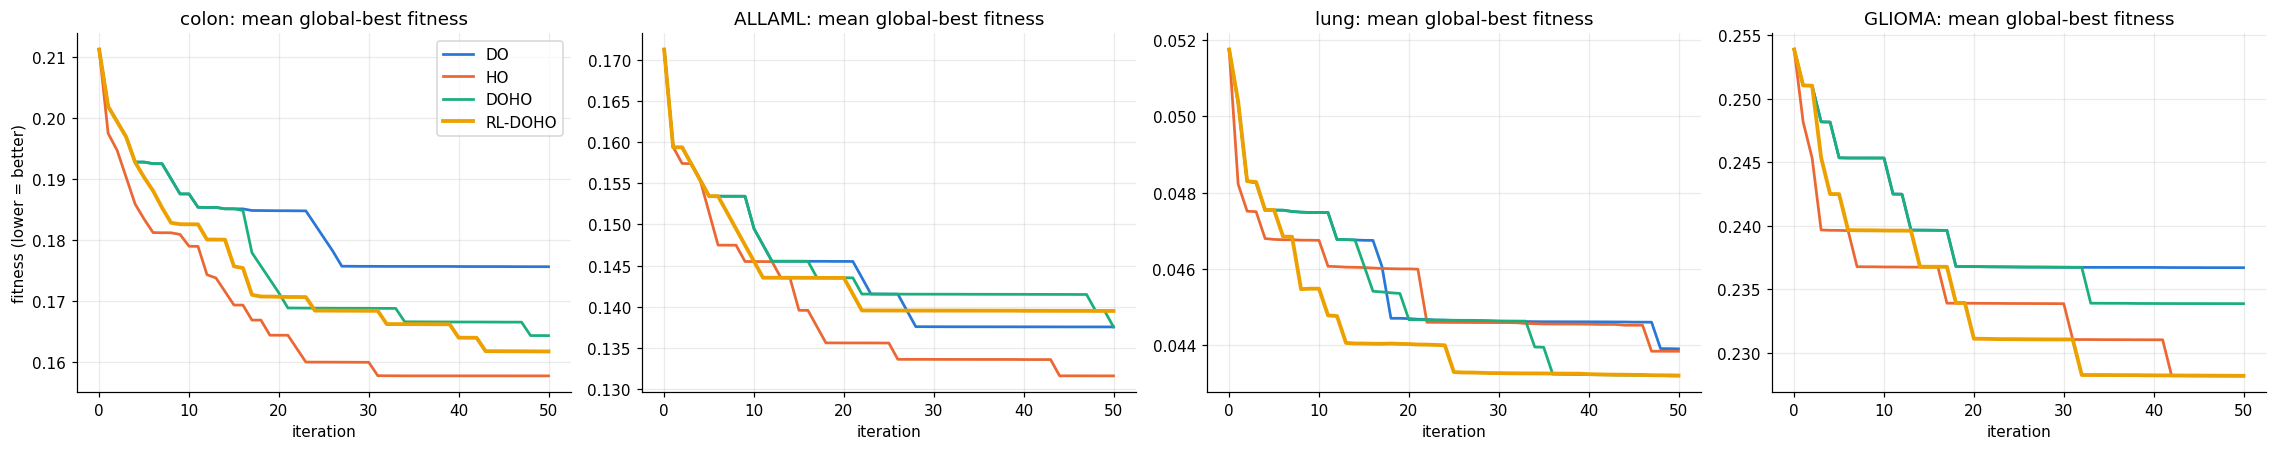

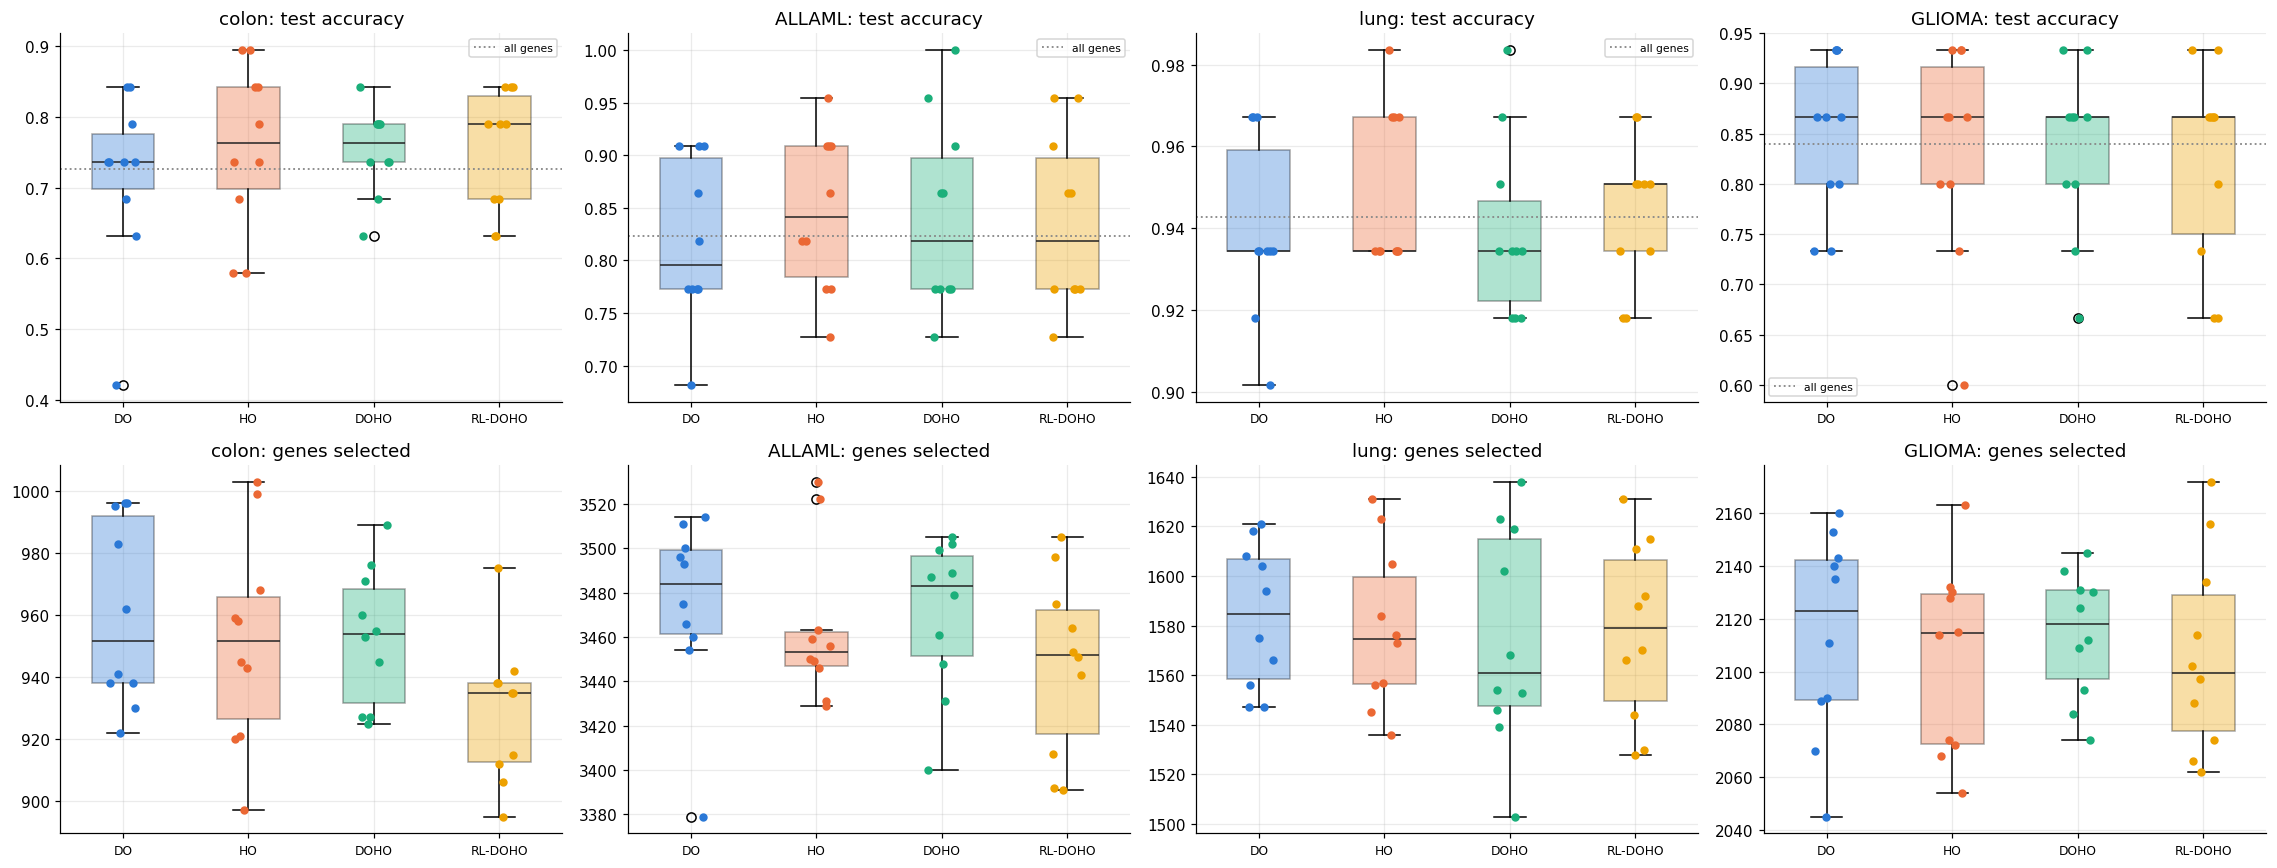

In [15]:
# Mean convergence per dataset (one panel per dataset), and test accuracy / genes per dataset
nd = len(DATASETS)
fig, ax = plt.subplots(1, nd, figsize=(5.2 * nd, 4.2))
for k, ds in enumerate(DATASETS):
    for a in ALGOS:
        B = np.vstack([runs[(ds, a, s)]["hist"]["best"].values for s in SEEDS])
        ax[k].plot(B.mean(0), color=COLORS[a], label=a, lw=2.5 if a == PROPOSED else 1.8)
    ax[k].set_title(f"{ds}: mean global-best fitness"); ax[k].set_xlabel("iteration")
ax[0].set_ylabel("fitness (lower = better)"); ax[0].legend()
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/03_convergence_per_dataset.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(2, nd, figsize=(5.2 * nd, 8))
jit = np.random.default_rng(0)
for k, ds in enumerate(DATASETS):
    for row, (col, title) in enumerate([("test_acc", "test accuracy"), ("n_feats", "genes selected")]):
        data = [summary[(summary.dataset == ds) & (summary.algo == a)][col].values for a in ALGOS]
        bp = ax[row, k].boxplot(data, widths=0.5, patch_artist=True, medianprops=dict(color="#222"))
        for patch, a in zip(bp["boxes"], ALGOS): patch.set_facecolor(COLORS[a]); patch.set_alpha(0.35)
        for i, (d, a) in enumerate(zip(data, ALGOS)):
            ax[row, k].scatter(i + 1 + jit.uniform(-0.12, 0.12, len(d)), d, color=COLORS[a], s=20, zorder=3)
        ax[row, k].set_xticks(range(1, len(ALGOS) + 1)); ax[row, k].set_xticklabels(ALGOS, fontsize=8)
        ax[row, k].set_title(f"{ds}: {title}")
        if row == 0: ax[row, k].axhline(allg[ds], color="#888", ls=":", lw=1.2, label="all genes"); ax[row, k].legend(fontsize=7)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/04_test_acc_and_genes.png", bbox_inches="tight"); plt.show()

## 10. Ablation across datasets: which parts of RL-DOHO matter?
In Notebook 1, PERTURB-only was best on a single small dataset. The argument for an adaptive controller is that **no single fixed arm is best on every dataset**. This section tests that directly.


[17:27:26] ablation colon seed 0: RL-DOHO=0.1667  Random arm=0.1888  Without HO arm=0.1423  PERTURB only=0.1916  Q-learning controller=0.1919  No local search=0.1892

[17:27:53] ablation colon seed 1: RL-DOHO=0.1174  Random arm=0.0954  Without HO arm=0.0956  PERTURB only=0.0955  Q-learning controller=0.1175  No local search=0.1175

[17:28:22] ablation colon seed 2: RL-DOHO=0.1424  Random arm=0.1423  Without HO arm=0.1670  PERTURB only=0.1422  Q-learning controller=0.1420  No local search=0.1671

[17:28:50] ablation colon seed 3: RL-DOHO=0.1697  Random arm=0.1916  Without HO arm=0.1917  PERTURB only=0.1697  Q-learning controller=0.1477  No local search=0.1919

[17:29:18] ablation colon seed 4: RL-DOHO=0.2108  Random arm=0.1890  Without HO arm=0.1889  PERTURB only=0.1890  Q-learning controller=0.1888  No local search=0.2109

[17:29:47] ablation colon seed 5: RL-DOHO=0.1642  Random arm=0.1643  Without HO arm=0.1641  PERTURB only=0.1862  Q-learning controller=0.1422  No local search=0.186

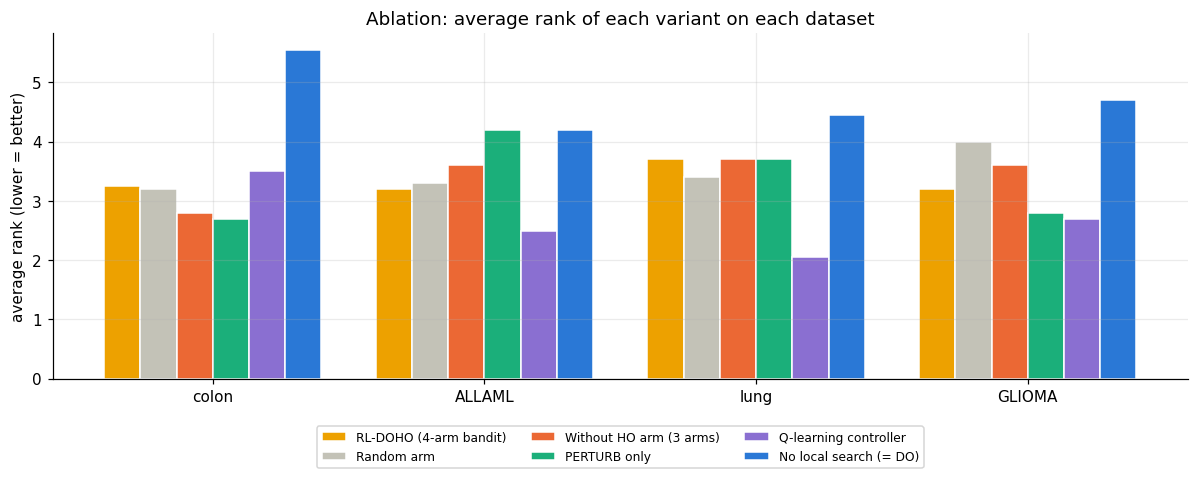

In [16]:
B4 = dict(verbose=VERBOSE)
ABL = {
    "RL-DOHO (4-arm bandit)":  None,
    "Random arm":              lambda s, n: rl_doho(seed=s, name=n, bandit=lambda sd: RandomArm(n_arms=4, seed=sd), **B4),
    "Without HO arm (3 arms)": lambda s, n: rl_doho(seed=s, name=n, arms=("PERTURB", "RESTART", "DO"), **B4),
    "PERTURB only":            lambda s, n: rl_doho(seed=s, name=n, bandit=lambda sd: FixedArm(0, sd, n_arms=4), **B4),
    "Q-learning controller":   lambda s, n: rl_doho_qlearning(seed=s, name=n, **B4),
    "No local search (= DO)":  "DO",
}
ABL_NAMES = list(ABL)
ABL_COL = dict(zip(ABL_NAMES, ["#eda100", "#c3c2b7", "#eb6834", "#1baf7a", "#8a6fd1", "#2a78d6"]))

if RUN_ABLATION:
    ABL_FILE = f"{OUT_DIR}/hd_ablation_p{POP_SIZE}_i{MAX_ITER}.pkl"
    abl = pickle.load(open(ABL_FILE, "rb")) if os.path.exists(ABL_FILE) else {}
    for ds in DATASETS:
        for s in SEEDS:
            todo = [n for n in ABL_NAMES if (ds, n, s) not in abl]
            if not todo: continue
            use_dataset(ds, s)
            for n in todo:
                fn = ABL[n]
                if fn is None or fn == "DO":
                    r = runs[(ds, PROPOSED if fn is None else "DO", s)]
                    abl[(ds, n, s)] = {k: r[k] for k in ("fit", "cv_acc", "test_acc", "n_feats")}
                else:
                    m, f, h = fn(s, n); r = record(m, f, h)
                    abl[(ds, n, s)] = {k: r[k] for k in ("fit", "cv_acc", "test_acc", "n_feats")}
                pickle.dump(abl, open(ABL_FILE, "wb"))
            save_cache_now()
            print(f"\n[{time.strftime('%H:%M:%S')}] ablation {ds} seed {s}: " +
                  "  ".join(f"{n.split(' (')[0]}={abl[(ds, n, s)]['fit']:.4f}" for n in ABL_NAMES), flush=True)

    ab = pd.DataFrame([{"dataset": ds, "variant": n, "seed": s, **abl[(ds, n, s)]} for ds in DATASETS for n in ABL_NAMES for s in SEEDS])
    ab.to_csv(f"{OUT_DIR}/hd_ablation.csv", index=False)
    print("\nMean fitness per dataset (lower = better):")
    piv = ab.pivot_table(index="variant", columns="dataset", values="fit", aggfunc="mean").reindex(ABL_NAMES)[DATASETS]
    print(piv.round(4).to_string())
    # rank of each variant within every (dataset, seed), then averaged: the cross-dataset robustness measure
    ab["rank"] = ab.groupby(["dataset", "seed"])["fit"].rank()
    rk = ab.pivot_table(index="variant", columns="dataset", values="rank", aggfunc="mean").reindex(ABL_NAMES)[DATASETS]
    rk["OVERALL"] = ab.groupby("variant")["rank"].mean().reindex(ABL_NAMES)
    print("\nAverage rank (1 = best) per dataset and overall:"); print(rk.round(2).to_string())
    best_per_ds = piv.idxmin()
    print("\nBest variant per dataset:"); print(best_per_ds.to_string())

    print("\nWilcoxon over all datasets × seeds, RL-DOHO vs each variant (fitness):")
    base = ab[ab.variant == ABL_NAMES[0]].sort_values(["dataset", "seed"])["fit"].values
    for n in ABL_NAMES[1:]:
        other = ab[ab.variant == n].sort_values(["dataset", "seed"])["fit"].values
        d = base - other
        try: p = wilcoxon(base, other, zero_method="zsplit").pvalue
        except ValueError: p = np.nan
        print(f"  vs {n:24s} W/T/L={np.sum(d < -1e-12)}/{np.sum(np.abs(d) <= 1e-12)}/{np.sum(d > 1e-12)}  p={p:.4f}")

    fig, ax = plt.subplots(figsize=(11, 4.5))
    w = 0.8 / len(ABL_NAMES); xs = np.arange(len(DATASETS))
    for i, n in enumerate(ABL_NAMES):
        ax.bar(xs + i * w, rk.loc[n, DATASETS].values, width=w, color=ABL_COL[n], label=n, edgecolor="white", lw=1)
    ax.set_xticks(xs + w * (len(ABL_NAMES) - 1) / 2); ax.set_xticklabels(DATASETS)
    ax.set_ylabel("average rank (lower = better)"); ax.set_title("Ablation: average rank of each variant on each dataset")
    ax.legend(fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/05_ablation_ranks.png", bbox_inches="tight"); plt.show()

## 11. Overall ranking across all datasets

In [17]:
summary["rank"] = summary.groupby(["dataset", "seed"])["fit"].rank()
overall = summary.groupby("algo").agg(avg_rank=("rank", "mean"), mean_test_acc=("test_acc", "mean"),
                                      mean_genes=("n_feats", "mean")).reindex(ALGOS).sort_values("avg_rank")
print("Average rank over all datasets × seeds (1 = best):"); print(overall.round(3).to_string())
dsr = summary.groupby(["dataset", "algo"])["fit"].mean().unstack()[ALGOS]
try: print(f"\nFriedman across datasets (on mean fitness per dataset): p={friedmanchisquare(*[dsr[a] for a in ALGOS]).pvalue:.4f}")
except ValueError: pass
print(f"\nAll results, figures and CSVs are in: {OUT_DIR}")

Average rank over all datasets × seeds (1 = best):
         avg_rank  mean_test_acc  mean_genes
algo                                        
HO          2.025          0.846    2024.600
RL-DOHO     2.062          0.838    2015.200
DOHO        2.788          0.842    2027.850
DO          3.125          0.830    2033.025

Friedman across datasets (on mean fitness per dataset): p=0.0979

All results, figures and CSVs are in: /content/drive/MyDrive/rl_doho_results_hd
